In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_log_error, mean_squared_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression, SelectFromModel
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

cv = KFold(n_splits=5, shuffle=True, random_state=42)

## EDA

In [2]:
df = pd.read_csv('train.csv')
df = df.drop('ID', axis = 1)
df.head()

,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,20aa07010,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,38000000.0,0.0,0,0.0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,600000.0,0.0,0,0.0,0,0,0,0,0,2200000.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,10000000.0,0.0,0,0.0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,2000000.0,0.0,0,0.0,0,0,0,0,0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,14400000.0,0.0,0,0.0,0,0,0,0,0,2000000.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [3]:
df.shape

(4459, 4992)

In [4]:
counter = {}
for key in df.keys():
    a = df[key].dtype
    counter[a] = counter.get(a, 0) + 1
counter

{dtype('float64'): 1845, dtype('int64'): 3147}

### Все признаки числовые

In [5]:
Y = df['target']
Y_log = np.log1p(Y)
X = df.drop('target', axis=1)
Y.describe()

count    4.459000e+03
mean     5.944923e+06
std      8.234312e+06
min      3.000000e+04
25%      6.000000e+05
50%      2.260000e+06
75%      8.000000e+06
max      4.000000e+07
Name: target, dtype: float64

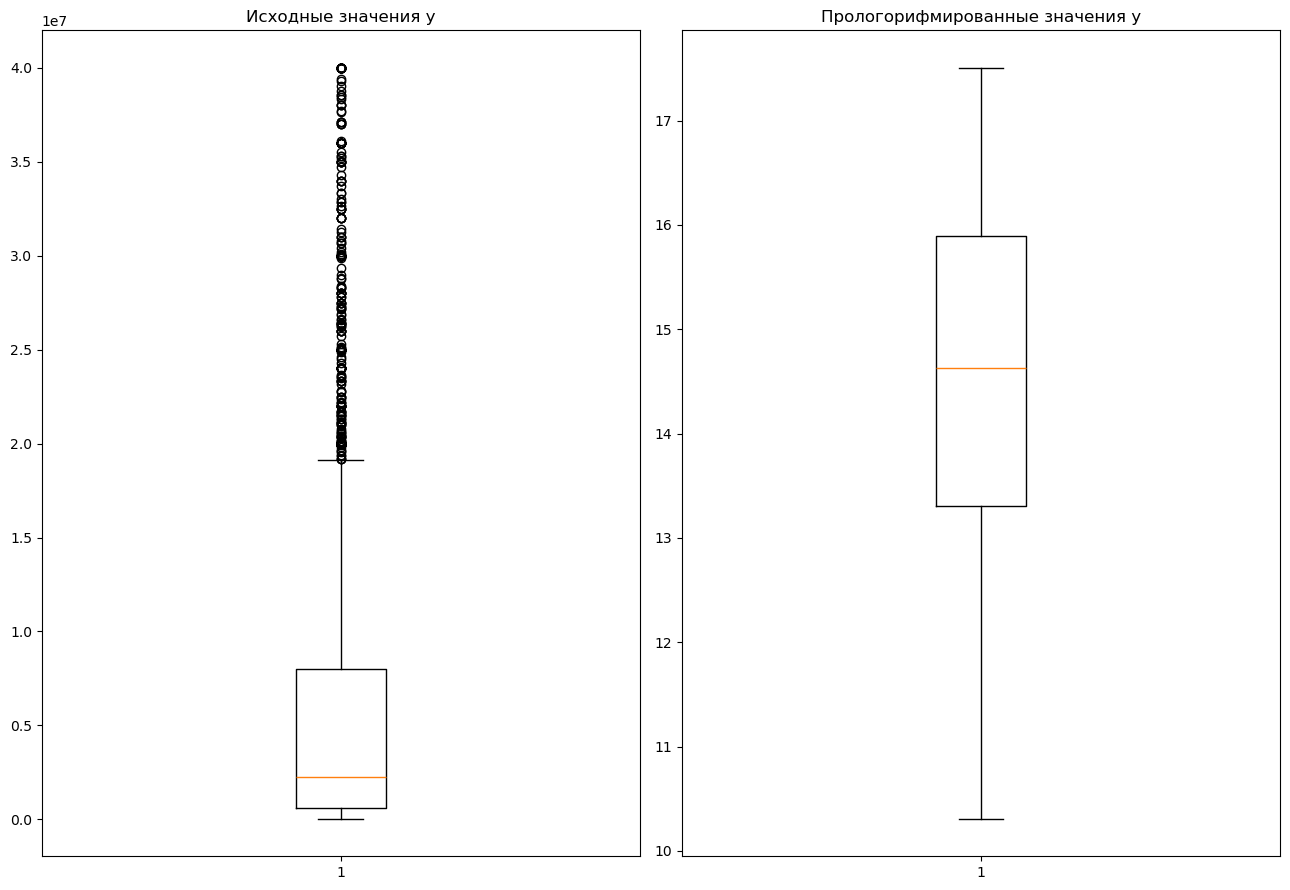

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 9))
axes[1].set_title('Прологорифмированные значения y')
axes[0].set_title('Исходные значения y')
axes[1].boxplot(Y_log)
axes[0].boxplot(Y)                        
plt.tight_layout(); plt.show()

### Y_log не имеет выбросов, будем работать с ним

доля нулей во всей матрице : 0.9685
ненулевых значений в строке: 157 из 4991


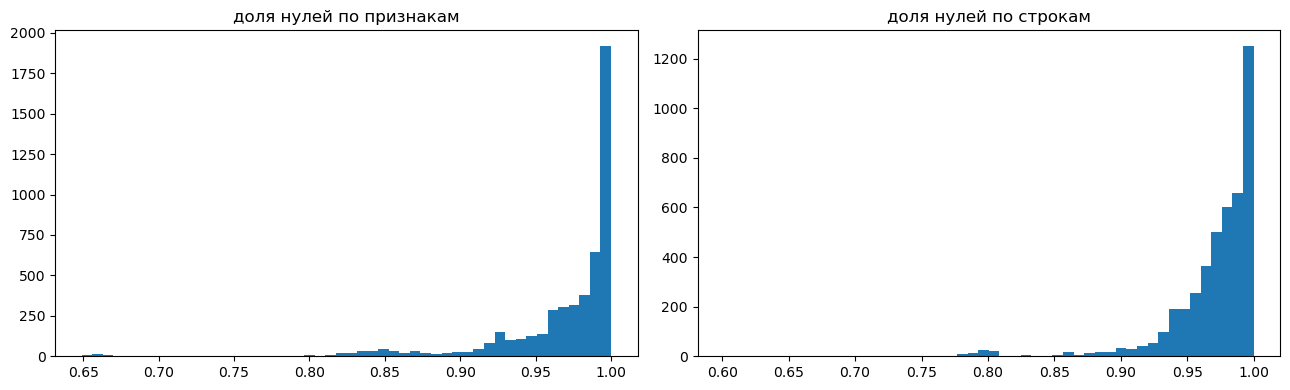

In [7]:
zero_share_col = (X == 0).mean()
zero_share_row = (X == 0).mean(axis=1)

print(f"доля нулей во всей матрице : {(X == 0).values.mean():.4f}")
print(f"ненулевых значений в строке: {(1 - zero_share_row).mean() * X.shape[1]:.0f} из {X.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(zero_share_col, bins=50)
axes[0].set_title("доля нулей по признакам")
axes[1].hist(zero_share_row, bins=50)
axes[1].set_title("доля нулей по строкам")
plt.tight_layout(); plt.show()

### Датасет разреженный, это поможет подобрать параметры для Future Engineering 

In [8]:
to_drop = []
for col in X.columns:
    if X[col].nunique() == 1 or X[col].isna().all():
        to_drop.append(col)
X = X.drop(columns=to_drop)
X.shape

(4459, 4735)

## Feature Engineering 

In [9]:
base_cols = X.columns.tolist()
stats = pd.DataFrame({
    'n_zeros':  (X[base_cols] == 0).sum(axis=1),
    'row_mean': X[base_cols].mean(axis=1),
    'row_max':  X[base_cols].max(axis=1),
    'row_sum':  X[base_cols].sum(axis=1),
}, index=X.index)
X = pd.concat([X, stats], axis=1)

In [10]:
corr = X.corrwith(Y_log)
corr.abs().sort_values(ascending=False).head(10)

row_sum      0.206092
row_mean     0.206092
9fd594eec    0.197227
f190486d6    0.195313
6eef030c1    0.194630
58e2e02e6    0.187259
70feb1494    0.173549
f74e8f13d    0.172804
26fc93eb7    0.172285
1702b5bf0    0.168431
dtype: float64

### Нет выделяющихся сильно коррелирующих с target признаков

## Подбор параметров всех моделей 

In [11]:
pipe_lgbm = Pipeline([
    ('select', SelectFromModel(
        LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=-1),
        threshold=-np.inf
    )),
    ('model', LGBMRegressor(n_estimators=300, random_state=42, verbose=-1, n_jobs=-1))
])
param_dist = {
    'select__max_features': randint(10, 100),
    'model__n_estimators': randint(200, 800),
    'model__num_leaves': randint(8, 64),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.09),
    'model__min_child_samples': randint(5, 50),
}
search_lgbm = RandomizedSearchCV(
    pipe_lgbm, param_dist,
    n_iter=30, cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
search_lgbm.fit(X, Y_log)

print(f"best RMSLE: {-search_lgbm.best_score_:.4f}")
print(f"best params: {search_lgbm.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
best RMSLE: 1.3888
best params: {'model__learning_rate': np.float64(0.04498095607205338), 'model__max_depth': 4, 'model__min_child_samples': 28, 'model__n_estimators': 416, 'model__num_leaves': 52, 'select__max_features': 50}


In [12]:
model_cb = Pipeline([
    ('select', SelectFromModel(
        LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=1),
        threshold=-np.inf
    )),
    ('model', CatBoostRegressor(random_state=42, verbose=0, thread_count=1))
])
param_dist_cb = {
    'select__max_features': randint(20, 150),
    'model__iterations': randint(300, 800),
    'model__depth': randint(4, 10),
    'model__learning_rate': uniform(0.01, 0.09),
    'model__reg_lambda': uniform(1, 20),   
}
search_cb = RandomizedSearchCV(model_cb, param_dist_cb, n_iter=25, cv=cv,
                               scoring='neg_root_mean_squared_error',
                               random_state=42, n_jobs=-1, verbose=1)
search_cb.fit(X, Y_log)
print(f"CatBoost best RMSLE: {-search_cb.best_score_:.4f}")
print(f"CatBoost best params: {search_cb.best_params_}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x108b25bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x102a69bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  F

CatBoost best RMSLE: 1.3768
CatBoost best params: {'model__depth': 7, 'model__iterations': 754, 'model__learning_rate': np.float64(0.06489969920043588), 'model__reg_lambda': np.float64(17.663898234723288), 'select__max_features': 54}


In [13]:
model_xgb = Pipeline([
    ('select', SelectFromModel(
        LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=1),
        threshold=-np.inf
    )),
    ('model', XGBRegressor(random_state=42, n_jobs=1, tree_method='hist'))
])
param_dist_xgb = {
    'select__max_features': randint(20, 150),
    'model__n_estimators': randint(200, 800),
    'model__max_depth': randint(3, 8),
    'model__learning_rate': uniform(0.01, 0.09),
    'model__subsample': uniform(0.6, 0.4),
}
search_xgb = RandomizedSearchCV(model_xgb, param_dist_xgb, n_iter=25, cv=cv,
                                scoring='neg_root_mean_squared_error',
                                random_state=42, n_jobs=-1, verbose=1)
search_xgb.fit(X, Y_log)
print(f"XGB best RMSLE: {-search_xgb.best_score_:.4f}")
print(f"XGB best params: {search_xgb.best_params_}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
XGB best RMSLE: 1.3839
XGB best params: {'model__learning_rate': np.float64(0.024041677639819285), 'model__max_depth': 5, 'model__n_estimators': 414, 'model__subsample': np.float64(0.6232334448672797), 'select__max_features': 107}


In [14]:
pipe_rf = Pipeline([
    ('select', SelectFromModel(
        LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=1),
        threshold=-np.inf
    )),
    ('model', RandomForestRegressor(random_state=42, n_jobs=1))
])

param_dist_rf = {
    'select__max_features': randint(10, 100),
    'model__n_estimators': randint(300, 500),
    'model__max_depth': randint(10, 40),
    'model__min_samples_leaf': randint(1, 20),
    'model__max_features': uniform(0.2, 0.8),
}

search_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=25, cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)
search_rf.fit(X, Y_log)
print(f"RF best RMSLE: {-search_rf.best_score_:.4f}")
print(f"RF best params: {search_rf.best_params_}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
RF best RMSLE: 1.3828
RF best params: {'model__max_depth': 17, 'model__max_features': np.float64(0.41977743439205134), 'model__min_samples_leaf': 3, 'model__n_estimators': 492, 'select__max_features': 56}


In [15]:
print(search_cb.best_params_)

from sklearn.base import clone
m = CatBoostRegressor(random_state=42, verbose=0, thread_count=1)
print("чистый CatBoost клонируется:", clone(m) is not None)

{'model__depth': 7, 'model__iterations': 754, 'model__learning_rate': np.float64(0.06489969920043588), 'model__reg_lambda': np.float64(17.663898234723288), 'select__max_features': 54}
чистый CatBoost клонируется: True


In [16]:
from sklearn.model_selection import cross_val_predict
best = search_cb.best_params_

fresh_cb = Pipeline([
    ('select', SelectFromModel(
        LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=1),
        threshold=-np.inf,
        max_features=int(best['select__max_features'])
    )),
    ('model', CatBoostRegressor(
        iterations=int(best['model__iterations']),
        depth=int(best['model__depth']),
        learning_rate=float(best['model__learning_rate']),
        reg_lambda=float(best['model__reg_lambda']), 
        random_state=42, verbose=0, thread_count=1
    ))
])

pred_cb = cross_val_predict(fresh_cb, X, Y_log, cv=cv)
pred_lgbm = cross_val_predict(search_lgbm.best_estimator_, X, Y_log, cv=cv)
pred_xgb  = cross_val_predict(search_xgb.best_estimator_,  X, Y_log, cv=cv)
pred_rf   = cross_val_predict(search_rf.best_estimator_,   X, Y_log, cv=cv)

preds_df = pd.DataFrame({'lgbm': pred_lgbm, 'cb': pred_cb,
                         'xgb': pred_xgb, 'rf': pred_rf})
for c in preds_df:
    print(f"{c}: {np.sqrt(mean_squared_error(Y_log, preds_df[c])):.4f}")
print(preds_df.corr().round(3))

lgbm: 1.3890
cb: 1.3770
xgb: 1.3841
rf: 1.3832
       lgbm     cb    xgb     rf
lgbm  1.000  0.964  0.952  0.949
cb    0.964  1.000  0.958  0.955
xgb   0.952  0.958  1.000  0.956
rf    0.949  0.955  0.956  1.000


все еще высокие corr, попробую добавить Lasso 

In [17]:
pipe_lasso = Pipeline([
    ('select', SelectFromModel(
        LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=1),
        max_features=50, threshold=-np.inf
    )),
    ('scale', StandardScaler()),
    ('model', LassoCV(cv=3, random_state=42, n_jobs=-1, max_iter=5000))
])
pred_lasso = cross_val_predict(pipe_lasso, X, Y_log, cv=cv)
print(f"Lasso RMSLE: {np.sqrt(mean_squared_error(Y_log, pred_lasso)):.4f}")

pipe_lasso.fit(X, Y_log)

Lasso RMSLE: 1.6420


Pipeline(steps=[('select',
                 SelectFromModel(estimator=LGBMRegressor(n_estimators=200,
                                                         n_jobs=1,
                                                         random_state=42,
                                                         verbose=-1),
                                 max_features=50, threshold=-inf)),
                ('scale', StandardScaler()),
                ('model',
                 LassoCV(cv=3, max_iter=5000, n_jobs=-1, random_state=42))])

In [18]:
preds_df['l1'] = pred_lasso
print(preds_df.corr())

          lgbm        cb       xgb        rf        l1
lgbm  1.000000  0.963513  0.952223  0.948950  0.546638
cb    0.963513  1.000000  0.958153  0.954783  0.542331
xgb   0.952223  0.958153  1.000000  0.955707  0.538284
rf    0.948950  0.954783  0.955707  1.000000  0.538919
l1    0.546638  0.542331  0.538284  0.538919  1.000000


In [19]:
stacker = LinearRegression(positive=True)
stack_pred = cross_val_predict(stacker, preds_df, Y_log, cv=cv)

rmsle_stack = np.sqrt(mean_squared_error(Y_log, stack_pred))
print(f"Stacking RMSLE: {rmsle_stack:.4f}")

Stacking RMSLE: 1.3707


In [20]:
df_test = pd.read_csv('test.csv')
test_ids = df_test['ID']

ROW_FEATS = ['n_zeros', 'row_mean', 'row_max', 'row_sum']
base_cols = [c for c in X.columns if c not in ROW_FEATS]

X_test = df_test[base_cols].copy()

X_test['n_zeros'] = (X_test[base_cols] == 0).sum(axis=1)
X_test['row_mean'] = X_test[base_cols].mean(axis=1)
X_test['row_max'] = X_test[base_cols].max(axis=1)
X_test['row_sum'] = X_test[base_cols].sum(axis=1)

X_test = X_test[X.columns]

In [21]:
stacker_final = LinearRegression(positive=True)
stacker_final.fit(preds_df, Y_log)

final_preds_df = pd.DataFrame({
    'lgbm': search_lgbm.best_estimator_.predict(X_test),
    'cb':   search_cb.best_estimator_.predict(X_test),
    'xgb':  search_xgb.best_estimator_.predict(X_test),
    'rf':   search_rf.best_estimator_.predict(X_test),
    'l1':   pipe_lasso.predict(X_test),
})[preds_df.columns]

pred_log = stacker_final.predict(final_preds_df)
pred = np.clip(np.expm1(pred_log), 0, None)

submission = pd.DataFrame({'ID': test_ids, 'target': pred})
submission.to_csv('submission.csv', index=False)